# Comparison of Reasoning Classification: Regular vs Baseline with Sys Instruct (GLM 4.7)

This notebook explores the difference in reasoning classification for the same problems between:
1. `logs/facts_one_hop/glm_4_7/analysis_by_gemini_3_flash.csv` (Regular)
2. `logs/facts_one_hop/glm_4_7/baseline_with_sys_instruct_analysis_by_gemini_3_flash.csv` (With Sys Instruct)

**Note:** "Classification" refers to the four confidence levels identified by the judge: `TABULA_RASA`, `WEAK_GUESS`, `STRONG_HYPOTHESIS`, and `NO_SEARCH`.

In [1]:
import pandas as pd
import glob
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Define directories and paths
LOG_DIR = "../logs/facts_one_hop/gemini_3_pro"
REGULAR_CSV = os.path.join(LOG_DIR, "analysis_by_gemini_3_flash.csv")
SYS_INSTRUCT_CSV = os.path.join(LOG_DIR, "baseline_with_sys_instruct_analysis_by_gemini_3_flash.csv")

# Trace files
REGULAR_TRACES_JSON = os.path.join(LOG_DIR, "baseline_run_1_traces_20260122_150159.json")
SYS_INSTRUCT_TRACES_JSON = os.path.join(LOG_DIR, "baseline_agent_with_sys_instruct_traces_20260209_103730.json")

def load_no_search_baseline(json_dir):
    pattern = os.path.join(json_dir, '*no_search*.json')
    files = glob.glob(pattern)
    
    if not files:
        print(f"Warning: No no-search JSON files found in {json_dir}")
        return None
        
    print(f"Found {len(files)} no-search run files.")
    
    correct_counts = {}
    
    for filepath in files:
        try:
            with open(filepath, 'r') as f:
                data = json.load(f)
                for item in data:
                    pid = item.get('problem')
                    if pid not in correct_counts:
                        correct_counts[pid] = 0
                    if item.get('sampler_correct', False):
                        correct_counts[pid] += 1
        except Exception as e:
            print(f"Error loading {filepath}: {e}")
            
    # A question is stable correct if it was correct in all 5 runs
    stable_probs = [pid for pid, count in correct_counts.items() if count == 5]
    print(f"Identified {len(stable_probs)} questions with stable correct answers (5/5).")
    return stable_probs

def load_thinking_traces(json_path):
    if not os.path.exists(json_path):
        print(f"Error: {json_path} not found.")
        return {}
    
    traces = {}
    try:
        with open(json_path, 'r') as f:
            data = json.load(f)
            for item in data:
                problem = item.get('problem', '')
                # Usually the trace is in the 3rd message (index 2) of message_trace
                message_trace = item.get('message_trace', [])
                if len(message_trace) > 2:
                    content = message_trace[2].get('parts', [{}])[0].get('content', '')
                    # Extract thinking if it's there (sometimes it's just text)
                    traces[problem] = content
    except Exception as e:
        print(f"Error loading traces from {json_path}: {e}")
    return traces

def get_from_stable_map(pid, data_map):
    clean_pid = pid.replace('...', '')
    for full_pid, value in data_map.items():
        if full_pid.startswith(clean_pid):
            return value
    return None

def load_and_preprocess(csv_path, stable_probs=None, traces=None):
    if not os.path.exists(csv_path):
        print(f"Error: {csv_path} not found.")
        return None
    
    try:
        df = pd.read_csv(csv_path)
        print(f"Loaded raw data from {os.path.basename(csv_path)}: {len(df)} rows.")
    except Exception as e:
        print(f"Error reading CSV: {e}")
        return None

    column_mapping = {
        'judge1_confidence': 'pre_search_confidence',
        'judge2_hypothesis_correct': 'hypothesis_correct',
        'judge2_query_biased': 'is_search_query_biased',
        'judge2_snippet_has_answer': 'snippet_has_answer',
        'judge2_answer_flipped': 'answer_flipped'
    }
    df.rename(columns=column_mapping, inplace=True)

    bool_cols = ['agent_correct', 'snippet_has_answer', 'answer_flipped', 'is_search_query_biased']
    for col in bool_cols:
        if col in df.columns:
            df[col] = df[col].astype(str).map({'True': True, 'False': False, '1': True, '0': False, '1.0': True, '0.0': False})
            df[col] = df[col].fillna(False)

    if stable_probs is not None:
        df['baseline_correct'] = df['problem_id'].apply(lambda x: any(p.startswith(x.replace('...', '')) for p in stable_probs))

    if traces is not None:
        df['thinking_trace'] = df['problem_id'].apply(lambda x: get_from_stable_map(x, traces))

    return df

# Load data
stable_probs = load_no_search_baseline(LOG_DIR)
reg_traces = load_thinking_traces(REGULAR_TRACES_JSON)
sys_traces = load_thinking_traces(SYS_INSTRUCT_TRACES_JSON)

# Load and preprocess both datasets
df_reg = load_and_preprocess(REGULAR_CSV, stable_probs, reg_traces)
df_sys = load_and_preprocess(SYS_INSTRUCT_CSV, stable_probs, sys_traces)

print("Preprocessing complete.")

Found 5 no-search run files.
Identified 37 questions with stable correct answers (5/5).
Loaded raw data from analysis_by_gemini_3_flash.csv: 98 rows.
Loaded raw data from baseline_with_sys_instruct_analysis_by_gemini_3_flash.csv: 98 rows.
Preprocessing complete.


In [2]:
# Merge for comparison
comparison_df = pd.merge(
    df_reg,
    df_sys,
    on='problem_id',
    suffixes=('_reg', '_sys')
)

print(f"Merged data size: {len(comparison_df)}")

Merged data size: 98


## 1. Confidence Classification Shift

Analyzing how the 4 classes (`TABULA_RASA`, `WEAK_GUESS`, `STRONG_HYPOTHESIS`, `NO_SEARCH`) changed between conditions.

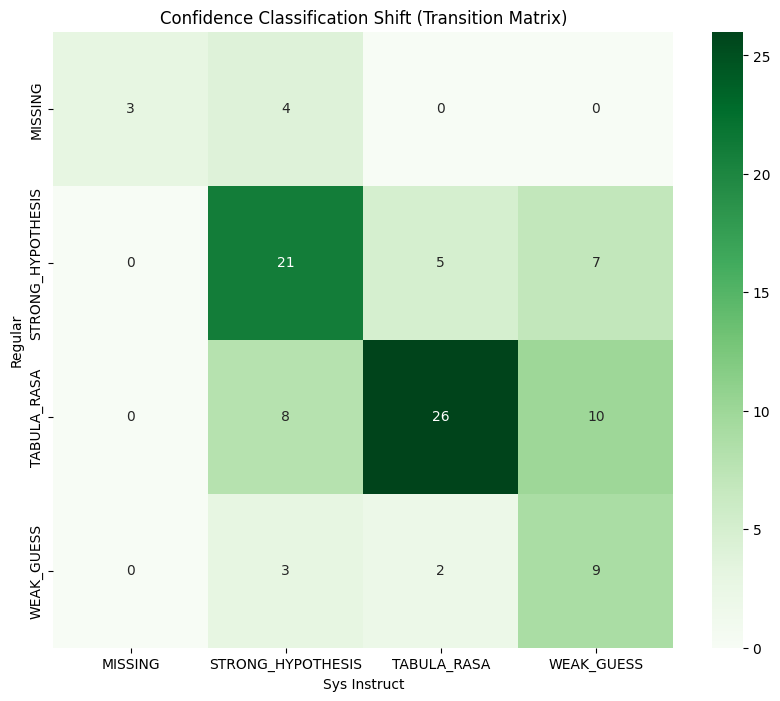

Number of problems where confidence classification changed: 42 out of 98 (42.9%)


In [3]:
conf_ct = pd.crosstab(
    comparison_df['pre_search_confidence_reg'].fillna('MISSING'),
    comparison_df['pre_search_confidence_sys'].fillna('MISSING'),
    rownames=['Regular'],
    colnames=['Sys Instruct']
)

plt.figure(figsize=(10, 8))
sns.heatmap(conf_ct, annot=True, fmt='d', cmap='Greens')
plt.title('Confidence Classification Shift (Transition Matrix)')
plt.show()

comparison_df['confidence_changed'] = comparison_df['pre_search_confidence_reg'] != comparison_df['pre_search_confidence_sys']
conf_change_count = comparison_df['confidence_changed'].sum()
print(f"Number of problems where confidence classification changed: {conf_change_count} out of {len(comparison_df)} ({conf_change_count/len(comparison_df):.1%})")

## 2. Reasoning Hypothesis Analysis

Did the actual reasoning (hypothesis) change for the same problems? We handle empty hypotheses (NaN) by treating them as empty strings.

In [4]:
# Normalize hypotheses for comparison
comparison_df['judge1_hypothesis_reg_clean'] = comparison_df['judge1_hypothesis_reg'].fillna('').astype(str).str.strip()
comparison_df['judge1_hypothesis_sys_clean'] = comparison_df['judge1_hypothesis_sys'].fillna('').astype(str).str.strip()

comparison_df['hypothesis_changed'] = (comparison_df['judge1_hypothesis_reg_clean'] != comparison_df['judge1_hypothesis_sys_clean'])

# Only count as changed if at least one of them is not empty
comparison_df['real_hypothesis_change'] = comparison_df['hypothesis_changed'] & \
                                         ((comparison_df['judge1_hypothesis_reg_clean'] != '') | \
                                          (comparison_df['judge1_hypothesis_sys_clean'] != ''))

hyp_change_count = comparison_df['real_hypothesis_change'].sum()
print(f"Number of problems where the judge's hypothesis actually changed (excluding empty to empty): {hyp_change_count} out of {len(comparison_df)} ({hyp_change_count/len(comparison_df):.1%})")

# Show examples where hypothesis changed
pd.set_option('display.max_colwidth', 300)
display_cols = ['problem_id', 'judge1_hypothesis_reg', 'judge1_hypothesis_sys']
comparison_df[comparison_df['real_hypothesis_change']][display_cols].head(10)

Number of problems where the judge's hypothesis actually changed (excluding empty to empty): 65 out of 98 (66.3%)


,problem_id,judge1_hypothesis_reg,judge1_hypothesis_sys
0,What is the most expensive article of clothing eve...,"The Nightingale of Kuala Lumpur is the most expensive article of clothing (specifically a dress), valued at $30 million, though Marilyn Monroe's 'Happy Birthday' dress holds the auction record at $4.8 million.","Marilyn Monroe's ""Happy Birthday"" dress or the Nightingale of Kuala Lumpur dress"
2,What was the year model of first ford vehicle to c...,"A 1925 Ford Model T (associated with Ed Flickenger and Perry Doolittle) is the primary candidate, though the agent doubts it meets the ""without assistance"" criteria due to its use of railway tracks.",The first Ford to complete an unassisted trans-Canada journey was a 1925 Ford Model T driven by Perry Doolittle.
3,Who was the doctor who diagnosed Flannery O'Connor...,NaN,Dr. Arthur J. Merrill diagnosed Flannery O'Connor with lupus.
7,In the first Premier League season Bukayo Saka sco...,"The first Premier League season where Bukayo Saka scored more than five goals was 2021-22, with a total of 11 goals.","In the 2021/22 Premier League season, Bukayo Saka scored 11 goals, which was his first season scoring more than five goals."
11,Who was the category manager of Q Acoustics in 200...,"The agent suspects that Steve Reichert, Alex Munro, or Tony Jones might be the person in question, but expresses significant doubt, calling it a ""long shot.""","The agent mentions Alex Munro and Steve Reichert as potential leads based on their association with the brand during that era, but expresses uncertainty regarding their specific titles and whether they held the 'Category Manager' role."
13,What specific award was the mobile game Candy Crus...,NaN,"The agent believes Candy Crush Saga might have been nominated for an award at the Kids' Choice Awards (specifically the ""Favorite Addicting Game"" category) or the People's Choice Awards in 2015, but also considers the IMGA as a possibility."
14,How many games in the 2020 ACC men's basketball to...,NaN,"The tournament was stopped on Thursday, likely during the quarterfinals."
15,who won the NFL MVP the year John Kerry lost the p...,NaN,"Peyton Manning won the NFL MVP for the 2004 season (the year Kerry lost). Peyton Manning and Steve McNair shared the 2003 MVP award, which was presented in early 2004."
17,What is the specific ancient source text that McMa...,Vegetius' De re militari (On Military Matters),"The agent does not identify a specific ancient text, but instead weighs several possibilities (Vegetius, Pausanias, or a medical text) and considers a potential connection to the recovery of Caligula's barges, expressing uncertainty about which one is the ""key motivator"" mentioned in the prompt."
18,What fast food restaurant did Sega games pair with...,The Sega CD-ROM fast food promotion involved Taco Bell or Pizza Hut.,"The agent believes Taco Bell is the most likely fast food chain to have partnered with Sega for a PC CD-ROM promotion, but it is explicitly unsure and acknowledges other possibilities like Pizza Hut or Burger King."


## 3. Manual Inspection: Deep Dive into Classification Changes

Inspecting problems with confidence classification changes, including the judge's hypothesis and the agent's initial thinking trace.

In [5]:
inspect_df = comparison_df[comparison_df['confidence_changed']].copy()

inspect_df['classification_change'] = inspect_df['pre_search_confidence_reg'].astype(str) + " -> " + inspect_df['pre_search_confidence_sys'].astype(str)

print(f"Found {len(inspect_df)} problems with confidence classification changes.\n")

for i, row in inspect_df.head(20).iterrows():
    print("="*100)
    print(f"PROBLEM: {row['problem_id']}")
    print(f"CHANGE:  {row['classification_change']}")
    print("-"*20 + " JUDGE HYPOTHESIS " + "-"*20)
    print(f"REGULAR: {row['judge1_hypothesis_reg']}")
    print(f"SYS INS: {row['judge1_hypothesis_sys']}")
    print("-"*20 + " THINKING TRACES " + "-"*20)
    print(f"REGULAR THINKING:\n{row['thinking_trace_reg']}")
    print(f"\nSYS INSTRUCT THINKING:\n{row['thinking_trace_sys']}")
    print("="*100 + "\n")

Found 42 problems with confidence classification changes.

PROBLEM: What is the most expensive article of clothing eve...
CHANGE:  STRONG_HYPOTHESIS -> WEAK_GUESS
-------------------- JUDGE HYPOTHESIS --------------------
REGULAR: The Nightingale of Kuala Lumpur is the most expensive article of clothing (specifically a dress), valued at $30 million, though Marilyn Monroe's 'Happy Birthday' dress holds the auction record at $4.8 million.
SYS INS: Marilyn Monroe's "Happy Birthday" dress or the Nightingale of Kuala Lumpur dress
-------------------- THINKING TRACES --------------------
REGULAR THINKING:
**My Analysis of the Most Expensive Article of Clothing**

Okay, so the task is to pinpoint the single most expensive article of clothing ever made as of January 2024. Immediately, I'm thinking I need to cast a wide net, looking at both auction records and incredibly high-value, possibly custom-made pieces. I need to be careful to differentiate between true "clothing" like dresses and suits